# 02 Getting Started Matplotlib

In [ ]:
# load dependencies. assumes already installed into python kernel.
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests

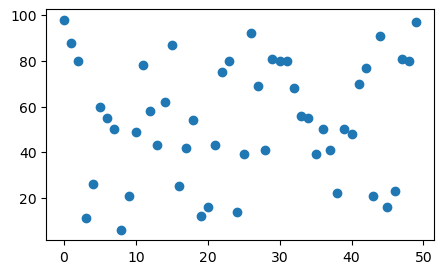

In [ ]:
# create a randomized dataset
np.random.seed(613)
x = np.arange(50)
y = np.random.randint(0, 100,50)

# create a scatterplot
fig, ax = plt.subplots(figsize=(5, 3))
ax.scatter(x,y)

<BarContainer object of 50 artists>

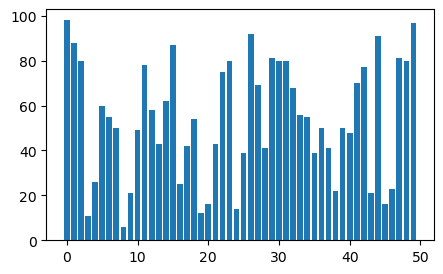

In [ ]:
# create a bar plot by using ax.bar()
fig, ax = plt.subplots(figsize=(5,3))
ax.bar(x,y)


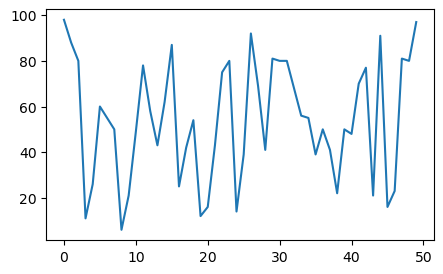

In [ ]:
# line chart with ax.plot()
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(x,y)

(array([4., 6., 2., 5., 7., 6., 4., 3., 9., 4.]),
 array([ 6. , 15.2, 24.4, 33.6, 42.8, 52. , 61.2, 70.4, 79.6, 88.8, 98. ]),
 <BarContainer object of 10 artists>)

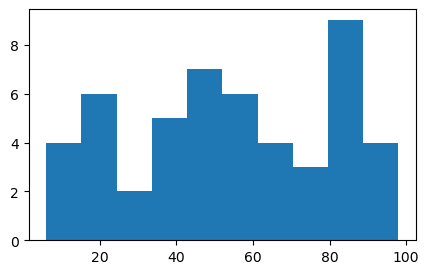

In [ ]:
# histogram with ax.hist()
fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(y)

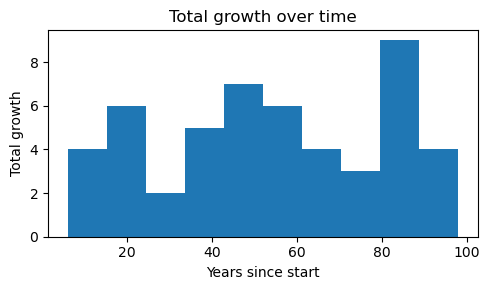

In [ ]:
# adding labels and titles to the graph
ax.set_title('Total growth over time') #title
ax.set_ylabel('Total growth') # y axis
ax.set_xlabel('Years since start') # x axis
fig.tight_layout() # make layout closer
fig

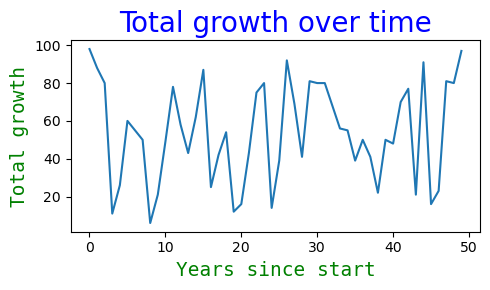

In [ ]:
# set fonts
font1 = {'family':'sans-serif','color':'blue','size':20}
font2 = {'family':'monospace', 'color':'green','size':14}

# show the result. use a line graph w/ ax.plot. add labels like previously
fig, ax = plt.subplots(figsize=(5,3))
ax.plot(x,y)
ax.set_title('Total growth over time', fontdict = font1)
ax.set_ylabel('Total growth', fontdict = font2)
ax.set_xlabel('Years since start', fontdict = font2)
fig.tight_layout()

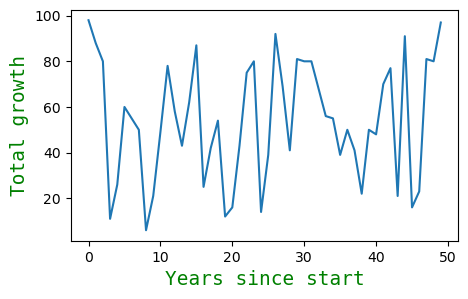

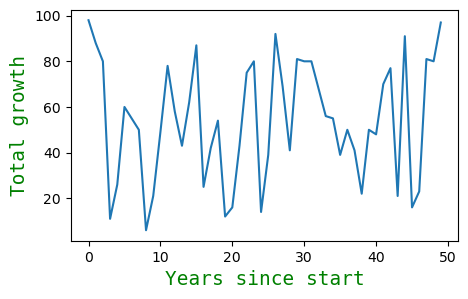

In [26]:
# revise the line chart to change the font of labels
fig, ax = plt.subplots(figsize=(5,3))
ax.plot(x,y)
ax.set_ylabel('Total growth', fontdict = font2) # ylabel font
ax.set_xlabel('Years since start', fontdict = font2) # x label font
fig

/var/folders/bm/zz3zwwtj491ggdvwhnvk_wyr0000gn/T/ipykernel_72329/1529735909.py:4: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


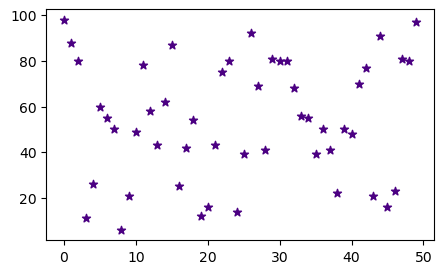

In [27]:
# revise marker for scatterplot
fig, ax = plt.subplots(figsize=(5,3))
ax.scatter(x, y, marker='*', color = "indigo")
fig.show()

/var/folders/bm/zz3zwwtj491ggdvwhnvk_wyr0000gn/T/ipykernel_72329/1221858484.py:4: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


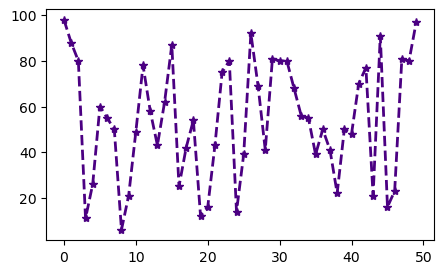

In [13]:
# change the colour too
fig, ax = plt.subplots(figsize=(5,3))
ax.plot(x, y, marker='*', color = 'indigo', linestyle = '--', linewidth=2)
fig.show()

/var/folders/bm/zz3zwwtj491ggdvwhnvk_wyr0000gn/T/ipykernel_72329/2663861060.py:3: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


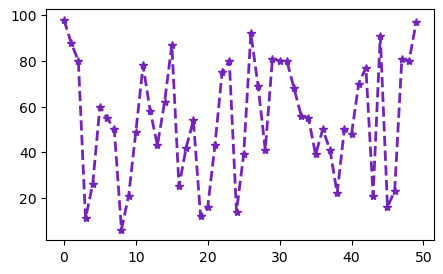

In [ ]:
# change the line width, line style, colour, and marker for the graph
fig, ax = plt.subplots(figsize=(5,3))
ax.plot(x,y,marker='*', color = '#7425b9', linestyle='--', linewidth=2)
fig.show()

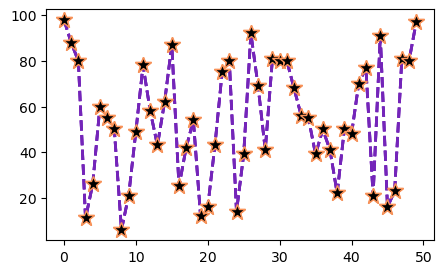

In [ ]:
# change the outline marker colours with markeredgecolor and markerfacecolor arguments.
ax.plot(x,y,marker='*', markersize=12, color='#7425b9', linestyle='--', linewidth=2, markeredgecolor='#fa9359', markerfacecolor='#000000')
fig

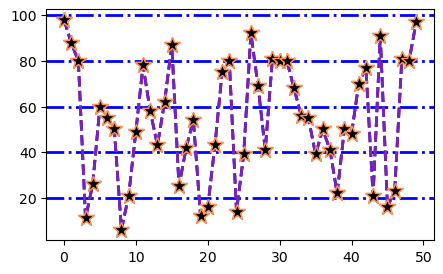

In [ ]:
# adding gridlines with ax.grid()
ax.grid(axis='y', color="blue", linewidth=2, linestyle='-.')
fig

### Activity
Visit the Python Graph Gallery at https://python-graph-gallery.com/all-charts/
Select one of the visualization types that you find most interesting
For your visualization of choice:
i. Copy the provided code and attempt to replicate the output in Python. NOTE: You
may have to install packages.
ii. Recall the aesthetic , substantive , and perceptual qualities of data
visualizations. Does your visualization of choice succeed in each area?
31


/Users/cbarron/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/categorical.py:2747: FutureWarning: The `inplace` parameter in pandas.Categorical.set_categories is deprecated and will be removed in a future version. Removing unused categories will always return a new Categorical object.
  res = method(*args, **kwargs)
/Users/cbarron/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/categorical.py:2747: FutureWarning: The `inplace` parameter in pandas.Categorical.set_categories is deprecated and will be removed in a future version. Removing unused categories will always return a new Categorical object.
  res = method(*args, **kwargs)
/Users/cbarron/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/categorical.py:2747: FutureWarning: The `inplace` parameter in pandas.Categorical.set_categories is deprecated and will be removed in a future version. Removing unused categories will always return a new Categorical object.
  res = method(*args, **kwargs)
find

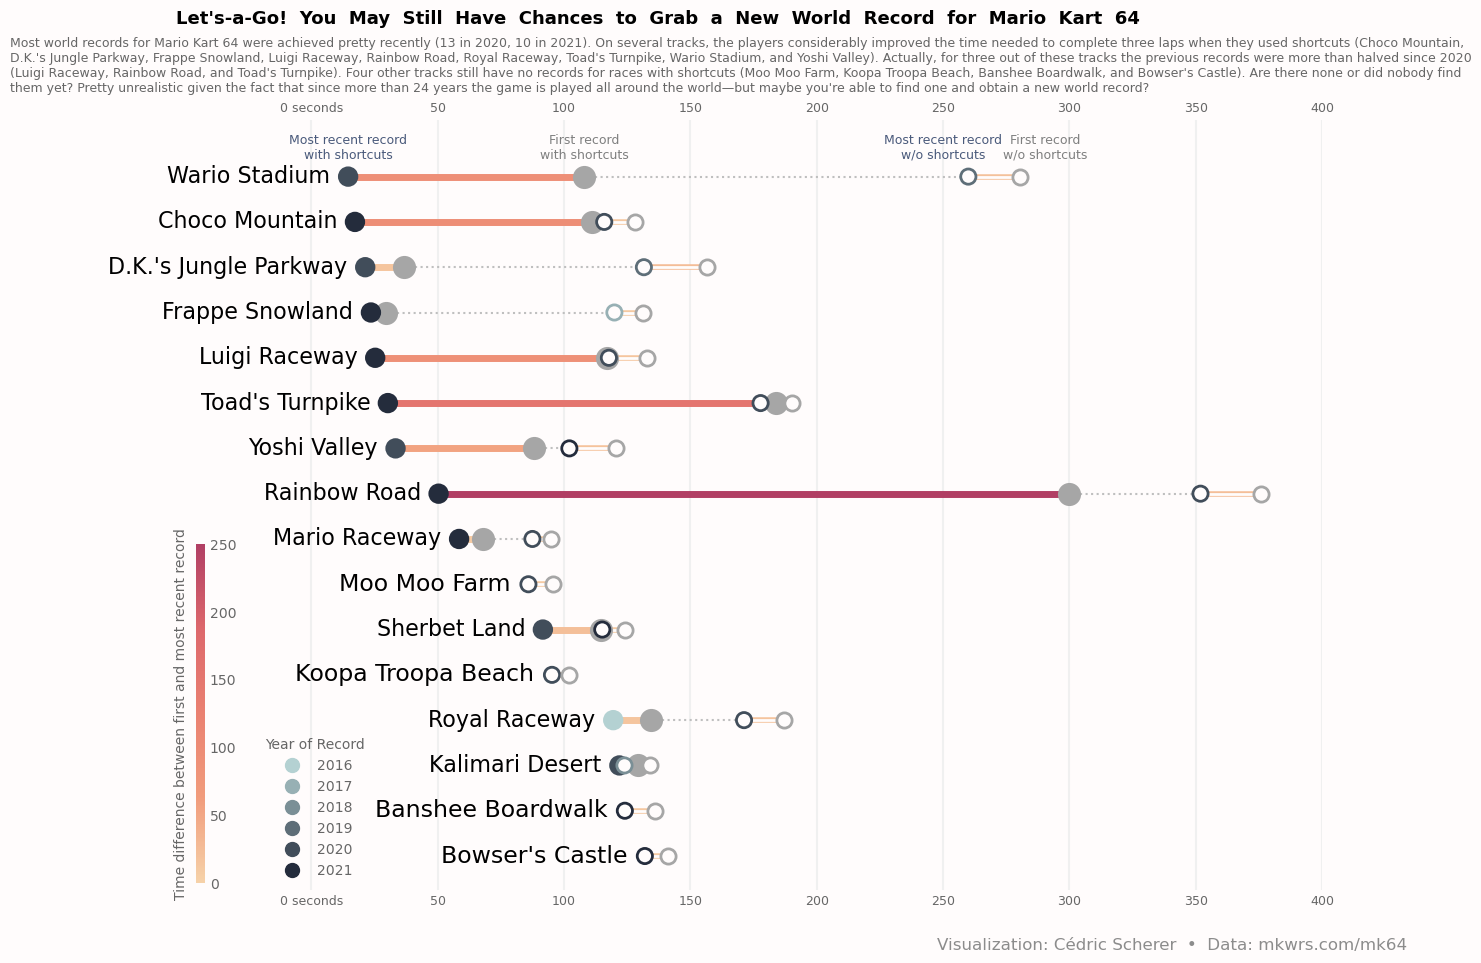

In [ ]:
# copying the code:
# Note: all code taken directly from https://python-graph-gallery.com/web-lollipop-plot-with-python-mario-kart-64-world-records/

import numpy as np
import pandas as pd
import matplotlib.colors as mc
import matplotlib.pyplot as plt

from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from palettable import cartocolors

# read data
df_records = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2021/2021-05-25/records.csv')
df_records.head(3)

# Keep records where type is Three Lap
df_rank = df_records.query("type == 'Three Lap'")

# Keep records with the minimum time for each track
df_rank = df_rank.loc[df_rank.groupby("track")["time"].idxmin()]

# Sort by descending time
df_rank = df_rank.sort_values("time", ascending=False)

# Make "track" ordered categorical with order given by descending times
# This categorical type will be used to sort the tracks in the plot.
df_rank["track"] = pd.Categorical(df_rank["track"], ordered=True,  categories=df_rank["track"])

# We call '.reset_index()' to avoid SettingWithCopyWarning
df_records_three = df_records.query("type == 'Three Lap'").reset_index() 
df_records_three["year"] = pd.DatetimeIndex(df_records_three["date"]).year

# First of all, for each track and shortcut, obtain the minimum and maximum
# value of time. These represent the most recent and first records, respectively.
df_connect = df_records_three.groupby(["track", "shortcut"]).agg(
    no = ("time", min),
    yes = ("time", max)
).reset_index()

# Next, put it into long format.
# Each row indicates the track, whether shortcuts were used, 
# if it's the current record, and the time achieved.
df_connect = pd.melt(
    df_connect,
    id_vars=["track", "shortcut"],
    value_vars=["no", "yes"],
    var_name="record",
    value_name="time"
)

# The dotted line goes from the first record without shortcut (the slowest)
# to the most recent record with shortcut (the fastest)
df_connect = df_connect.query(
    "(shortcut == 'No' and record == 'no') or (shortcut == 'Yes' and record == 'yes')"
)

# Finally it is put in wide format, where there's only one row per track.
df_connect = df_connect.pivot_table(index="track", columns="record", values="time").reset_index()

# Long dist refers to records without shortcut
df_longdist = df_records_three.query("shortcut == 'No'")

# Only keep observations referring to either the first or the most recent record, by track.
grouped = df_longdist.groupby("track")
df_longdist = df_longdist.loc[pd.concat([grouped["time"].idxmax(), grouped["time"].idxmin()])]

# Create a 'group' variable that indicates whether the record
# refers to the first record, the one with maximum time,
# or to the most recent record, the one with minimum time.
df_longdist.loc[grouped["time"].idxmax(), "group"] = "max"
df_longdist.loc[grouped["time"].idxmin(), "group"] = "min"

# 'year' records the year of the most recent record
df_longdist["year"] = df_longdist.groupby("track")['year'].transform(max)

# Put the data in wide format, i.e., one observation per track.
df_longdist = df_longdist.pivot_table(index=["track", "year"], columns="group", values="time").reset_index()
df_longdist["diff"] = df_longdist["max"] - df_longdist["min"]

# Same process than above, but using records where shortcut is "Yes"
df_shortcut = df_records_three.query("shortcut == 'Yes'")
grouped = df_shortcut.groupby("track")
df_shortcut = df_shortcut.loc[pd.concat([grouped["time"].idxmax(), grouped["time"].idxmin()])]
df_shortcut.loc[grouped["time"].idxmax(), "group"] = "max"
df_shortcut.loc[grouped["time"].idxmin(), "group"] = "min"

df_shortcut["year"] = df_shortcut.groupby("track")['year'].transform(max)
df_shortcut = df_shortcut.pivot_table(index=["track", "year"], columns="group", values="time").reset_index()
df_shortcut["diff"] = df_shortcut["max"] - df_shortcut["min"]

tracks_sorted = df_rank["track"].dtype.categories.tolist()

# Sort df_connect
df_connect["track"] = df_connect["track"].astype("category")
df_connect["track"].cat.set_categories(tracks_sorted, inplace=True)
df_connect = df_connect.sort_values("track")

# Sort df_longdist
df_longdist["track"] = df_longdist["track"].astype("category")
df_longdist["track"].cat.set_categories(tracks_sorted, inplace=True)
df_longdist = df_longdist.sort_values("track")

# Sort df_shortcut
df_shortcut["track"] = df_shortcut["track"].astype("category")
df_shortcut["track"].cat.set_categories(tracks_sorted, inplace=True)
df_shortcut = df_shortcut.sort_values("track")


GREY94 = "#f0f0f0"
GREY75 = "#bfbfbf"
GREY65 = "#a6a6a6"
GREY55 = "#8c8c8c"
GREY50 = "#7f7f7f"
GREY40 = "#666666"
LIGHT_BLUE = "#b4d1d2"
DARK_BLUE = "#242c3c"
BLUE = "#4a5a7b"
WHITE = "#FFFCFC" # technically not pure white

# We have two colormaps, one for orange and other for blue
colormap_orange = cartocolors.sequential.RedOr_5.mpl_colormap

# And we also create a new colormap using 
colormap_blue = mc.LinearSegmentedColormap.from_list("blue", [LIGHT_BLUE, DARK_BLUE], N=256)

fig, ax = plt.subplots(figsize = (15, 10))

# Add segments ---------------------------------------------------
# Dotted line connection shortcut yes/no
ax.hlines(y="track", xmin="yes", xmax="no", color=GREY75, ls=":", data=df_connect)

# Segment when shortcut==yes
# First time we use the colormap and the normalization
norm_diff = mc.Normalize(vmin=0, vmax=250)
color = colormap_orange(norm_diff(df_shortcut["diff"].values))
ax.hlines(y="track", xmin="min", xmax="max", color=color, lw=5, data=df_shortcut)

# Segment when shortcut==no. Note we are overlapping lineranges
# We use the same normalization scale.
color = colormap_orange(norm_diff(df_longdist["diff"].values))
ax.hlines(y="track", xmin="min", xmax="max", color=color, lw=4, data=df_longdist)
ax.hlines(y="track", xmin="min", xmax="max", color=WHITE, lw=2, data=df_longdist)


# Add dots -------------------------------------------------------
## Dots when shortcut==yes – first record
# zorder is added to ensure dots are on top
ax.scatter(x="max", y="track", s=200, color=GREY65, edgecolors=GREY65, lw=2.5, zorder=2, data=df_shortcut)

## Dots when shortcut==yes – latest record
# This time we normalize using the range of years in the data, and use blue colormap
norm_year = mc.Normalize(df_shortcut["year"].min(), df_shortcut["year"].max())
color = colormap_blue(norm_year(df_shortcut["year"].values))
ax.scatter(x="min", y="track", s=160, color=color, edgecolors=color, lw=2, zorder=2, data=df_shortcut)

## Dots shortcut==no – first record
color = colormap_blue(norm_year(df_longdist["year"].values))
ax.scatter(x="min", y="track", s=120, color=WHITE, edgecolors=color, lw=2, zorder=2, data=df_longdist)

## Dots shortcut==no – latest record
ax.scatter(x="max", y="track", s=120, color=WHITE, edgecolors=GREY65, lw=2, zorder=2, data=df_longdist)


# Add labels on the left side of the lollipops -------------------
# Annotations for tracks in df_shortcut
for row in range(df_shortcut.shape[0]):
     ax.text(
        df_shortcut["min"][row] - 7, 
        df_shortcut["track"][row], 
        df_shortcut["track"][row], 
        ha="right", 
        va="center",
        size=16, 
        color="black",
        fontname="Atlantis"
    )

# Annotations for df_longdist, not in df_shortcut
for row in range(df_longdist.shape[0]):
    if df_longdist["track"][row] not in df_shortcut["track"].values:
        ax.text(
            df_longdist["min"][row] - 7, 
            df_longdist["track"][row], 
            df_longdist["track"][row], 
            ha="right", 
            va="center",
            size=17,
            color="black",
            fontname="Atlantis",
        )

# Add labels on top of the first row of lollipops ----------------
# These labels are used to give information about the meaning of
# the different dots without having to use a legend.

# Label dots when shortcut==yes
df_shortcut_wario = df_shortcut.query("track == 'Wario Stadium'")
ax.text(
    df_shortcut_wario["min"], 
    df_shortcut_wario["track"], 
    "Most recent record\nwith shortcuts\n", 
    color=BLUE,
    ma="center",
    va="bottom",
    ha="center",
    size=9,
    fontname="Overpass"
)
ax.text(
    df_shortcut_wario["max"], 
    df_shortcut_wario["track"], 
    "First record\nwith shortcuts\n", 
    color=GREY50,
    ma="center",
    va="bottom",
    ha="center",
    size=9,
    fontname="Overpass"
)

# Label dots when shortcut==no
df_longdist_wario = df_longdist.query("track == 'Wario Stadium'")

ax.text(
    df_longdist_wario["min"] - 10, 
    df_longdist_wario["track"], 
    "Most recent record\nw/o shortcuts\n", 
    color=BLUE,
    ma="center",
    va="bottom",
    ha="center",
    size=9,
    fontname="Overpass"
)
ax.text(
    df_longdist_wario["max"] + 10, 
    df_longdist_wario["track"], 
    "First record\nw/o shortcuts\n", 
    color=GREY50,
    ma="center",
    va="bottom",
    ha="center",
    size=9,
    fontname="Overpass"
)

# Customize the layout -------------------------------------------

# Hide spines
ax.spines["left"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["bottom"].set_visible(False)

# Hide y labels
ax.yaxis.set_visible(False)

# Customize x ticks
# * Remove x axis ticks 
# * Put labels on both bottom and and top
# * Customize the tick labels. Only the first has the "seconds" appended.
ax.tick_params(axis="x", bottom=True, top=True, labelbottom=True, labeltop=True, length=0)
xticks = np.linspace(0, 400, num=9, dtype=int).tolist()
ax.set_xlim(-60, 400)
ax.set_xticks(xticks)
ax.set_xticklabels(["0 seconds"] + xticks[1:], fontname="Hydrophilia Iced", color=GREY40, size=9)

# Set background color for the subplot.
ax.set_facecolor(WHITE)


# Add thin vertical lines to serve as guide
# 'zorder=0' is imoprtant to they stay behind other elements in the plot.
for xtick in xticks:
    ax.axvline(xtick, color=GREY94, zorder=0)

# Add vertical space to the vertical limit in the plot
x0, x1, y0, y1 = plt.axis()
plt.axis((x0, x1, y0, y1 + 0.5));


# Add custom legends ---------------------------------------------

# Legend for time difference. 

# Recall the 'norm_diff()' created above.
# Create an inset axes with a given width and height.
cbaxes = inset_axes(
    ax, width="0.8%", height="44%", loc=3,
    bbox_to_anchor=(0.025, 0., 1, 1), 
    bbox_transform=ax.transAxes
) 

cb = fig.colorbar(
    ScalarMappable(norm=norm_diff, cmap=colormap_orange), cax=cbaxes, 
    ticks=[0, 50, 100, 150, 200, 250]
)

# Remove the outline of the colorbar
cb.outline.set_visible(False)

# Set label, playing with labelpad to put it in the right place
cb.set_label(
    "Time difference between first and most recent record", 
    labelpad=-45,
    color=GREY40, 
    size=10, 
    fontname="Overpass"
)

# Remove ticks in the colorbar with 'size=0'
cb.ax.yaxis.set_tick_params(
    color=GREY40,
    size=0
)

# Add ticklabels at given positions, with custom font and color
cb.ax.yaxis.set_ticklabels(
    [0, 50, 100, 150, 200, 250], 
    fontname="Hydrophilia Iced", 
    color=GREY40, 
    size=10
)

# Legend for year

# We create a custom function to put the Line2D elements into a list
# that then goes into the 'handle' argument of the 'ax.legend()'
years = [2016, 2017, 2018, 2019, 2020, 2021]
def legend_dot(year):
    line = Line2D(
        [0], 
        [0], 
        marker="o",
        markersize=10,
        linestyle="none",
        color=colormap_blue(norm_year(year)), 
        label=f"{year}"
    )
    return line

# Store the legend in a name because we use it to modify its elements
years_legend = ax.legend(
    title="Year of Record",
    handles=[legend_dot(year) for year in years], 
    loc=3, # lower left
    bbox_to_anchor=(0.08, 0, 1, 1),
    frameon=False
)

# Set font family, color and size to the elements in the legend
for text in years_legend.get_texts():
    text.set_fontfamily("Hydrophilia Iced")
    text.set_color(GREY40)
    text.set_fontsize(10)

# Same modifications, but applied to the title.
legend_title = years_legend.get_title()
legend_title.set_fontname("Overpass")
legend_title.set_color(GREY40)
legend_title.set_fontsize(10)

# The suptitle acts as the main title.
# Play with 'x' and 'y' to get them in the place you want.
plt.suptitle(
    "Let's-a-Go!  You  May  Still  Have  Chances  to  Grab  a  New  World  Record  for  Mario  Kart  64",
    fontsize=13,
    fontname="Atlantis Headline",
    weight="bold",
    x = 0.457,
    y = 0.99
    
)

subtitle = [
    "Most world records for Mario Kart 64 were achieved pretty recently (13 in 2020, 10 in 2021). On several tracks, the players considerably improved the time needed to complete three laps when they used shortcuts (Choco Mountain,",
    "D.K.'s Jungle Parkway, Frappe Snowland, Luigi Raceway, Rainbow Road, Royal Raceway, Toad's Turnpike, Wario Stadium, and Yoshi Valley). Actually, for three out of these tracks the previous records were more than halved since 2020", 
    "(Luigi Raceway, Rainbow Road, and Toad's Turnpike). Four other tracks still have no records for races with shortcuts (Moo Moo Farm, Koopa Troopa Beach, Banshee Boardwalk, and Bowser's Castle). Are there none or did nobody find", 
    "them yet? Pretty unrealistic given the fact that since more than 24 years the game is played all around the world—but maybe you're able to find one and obtain a new world record?"
]
# And the axis title acts as a subtitle.
ax.set_title(
    "\n".join(subtitle),
    loc="center",
    ha="center",
    ma="left",
    color=GREY40,
    fontname="Overpass",
    fontsize=9,
    pad=20
)

# Add legend
fig.text(
    0.8, .05, "Visualization: Cédric Scherer  •  Data: mkwrs.com/mk64", 
    fontname="Overpass", 
    fontsize=12, 
    color=GREY55, 
    ha="center"
)

# Set figure's background color, to match subplot background color.
fig.patch.set_facecolor(WHITE)

# Finally, save the plot!
plt.savefig(
    "mario-kart-64-world-records.png", 
    facecolor=WHITE, 
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.3
)

Answering the questions:

ii. Recall the aesthetic , substantive , and perceptual qualities of data
visualizations. Does your visualization of choice succeed in each area?

#### Aesthetic
Yes, this is a highly polished dumbell plot. 
The code removes unnecessary visual clutter ("chart junk"). It removes the top, bottom, left, and right spines (ax.spines["top"].set_visible(False)), hides the y-axis ticks, and uses very faint background grid lines (zorder=0, color GREY94) so they don't distract from the data.

The code uses specific fonts, and provides detailed titles, labels, and annotations to make it look like a polished infographic rather than a default Matplotlib output.

Color Usage: It uses a customized, sophisticated color palette. Rather than using harsh primary colors, it uses thoughtful gradients (a RedOr colormap for the lines and a custom Light Blue to Dark Blue colormap for the dots) combined with stark white and various shades of grey to keep the focus on the highlighted data.

#### Substantive
Yes, there is a clear narrative. The visualization portrays a specific story about human optimization over 24 years of gameplay. The descriptive title and detailed subtitle explicitly guide the reader to the main takeaways (e.g., which tracks still have unbroken records).

Plotting the first record alongside the most recent record in a dumbelll plot provides historical context (and emphasizes the difference between the two) By plotting the first record alongside the most recent record, it highlights the longitudinal difference across the two timepoints.


#### Perceptual qualities
It mostly succeeds, though it is fairly dense.

The task uses the most highly accurate perceptual task—position along a common scale (the x-axis)—to display the track times. The length of the "dumbbells" (the lines connecting the dots) makes it instantly perceptually obvious which tracks have seen the largest time improvements (like Wario Stadium and Rainbow Road). Furthermore, using a dotted line to vertically connect the "Shortcut" and "No Shortcut" records for the same track is a clever way to use spatial grouping to show relationships.

The chart is nonetheless quite complicated. While it mostly succeeds, reducing the complexity may be beneficial.